# CellMorphNet: TMB Prediction from Histopathology Images
## DSAI 305 Phase 2 - Explainable AI Project

**Model**: CellMorphNet (Xu et al., 2025)  
**Task**: Binary TMB classification (High ≥10 mut/Mb vs Low <1.1 mut/Mb)  
**Framework**: PyTorch 2.0.1  
**Explainability**: SHAP, LIME, PDP, Grad-CAM


In [1]:
# ## §1 — Imports & Environment Setup

import os
import sys
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# PyTorch & Torchvision
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torchvision.transforms as transforms
from torchvision import models

# Explainability libraries
import shap
from lime import lime_image
from skimage.segmentation import mark_boundaries
import cv2
import copy

# Metrics & stats
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
from scipy import stats

# Reproducibility
SEEDS = [42, 123, 456, 789, 1024]

def set_seed(seed: int):
    """Set all random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Device configuration
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")


/home/youssef_mohammad/projects/DSAI_305_XAI_PROJECT/DSAI_305_XAI/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [2]:
# ## §2 — Configuration & Paths

# Project root (relative paths from here)
PROJECT_ROOT = Path(__file__).parent.parent.parent.parent if '__file__' in dir() else Path.cwd()
while not (PROJECT_ROOT / 'data').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

# Data paths
DATA_DIR = PROJECT_ROOT / 'data'
TILES_DIR = DATA_DIR / 'processed' / 'tiles'
TABULAR_DIR = DATA_DIR / 'cbioportal_tabular_downloads'
CHECKPOINT_DIR = DATA_DIR / 'checkpoints'
FIGURES_DIR = Path('members/youssef/experiments/CellMorphNet/figures')
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Hyperparameters (from paper Section III-D)
CONFIG = {
    'input_size': 224,
    'batch_size': 64,
    'learning_rate': 1e-4,
    'optimizer': 'adamw',  # or 'lion'
    'weight_decay': 1e-4,
    'dropout': 0.2,
    'epochs': 30,
    'patience': 10,  # early stopping
    'factor': 0.5,   # LR reduction factor
    'min_lr': 1e-7,
    'num_classes': 2,  # binary: TMB-H vs TMB-L
    'tmb_high_threshold': 10.0,  # mut/Mb
    'tmb_low_threshold': 1.1,    # mut/Mb
}

print(f"Configuration loaded: {CONFIG}")


Configuration loaded: {'input_size': 224, 'batch_size': 64, 'learning_rate': 0.0001, 'optimizer': 'adamw', 'weight_decay': 0.0001, 'dropout': 0.2, 'epochs': 30, 'patience': 10, 'factor': 0.5, 'min_lr': 1e-07, 'num_classes': 2, 'tmb_high_threshold': 10.0, 'tmb_low_threshold': 1.1}


In [3]:
# ## §3 — Cellular Deconvolution Module (HED Stain Separation)

class CellularDeconvolution(nn.Module):
    """
    Implements stain separation using HED (Hematoxylin-Eosin-DAB) color deconvolution.
    Based on Ruifrok & Johnston method for histopathological image analysis.
    """
    def __init__(self, rgb_to_hed_matrix=None):
        super().__init__()
        # Default RGB->HED conversion matrix (from literature)
        if rgb_to_hed_matrix is None:
            # Standard HED matrix: rows = stains, cols = RGB channels
            self.register_buffer('deconv_matrix', torch.tensor([
                [0.650, 0.704, 0.286],  # Hematoxylin
                [0.072, 0.990, 0.105],  # Eosin
                [0.268, 0.570, 0.776],  # DAB (optional)
            ], dtype=torch.float32))
        else:
            self.register_buffer('deconv_matrix', rgb_to_hed_matrix)
        
        # Learnable refinement parameters (optional fine-tuning)
        self.refinement = nn.Parameter(torch.eye(3) * 0.01, requires_grad=True)
        
    def forward(self, rgb: torch.Tensor) -> torch.Tensor:
        """
        Args:
            rgb: Tensor of shape (B, 3, H, W) with values in [0, 1]
        Returns:
            hed: Tensor of shape (B, 3, H, W) with stain concentrations
        """
        B, C, H, W = rgb.shape
        assert C == 3, "Input must have 3 RGB channels"
        
        # Convert to optical density: OD = -log10(I/I0)
        # Add epsilon to avoid log(0)
        rgb_flat = rgb.clamp(1e-6, 1.0).reshape(B, C, -1)
        od = -torch.log10(rgb_flat + 1e-6)
        
        # Apply deconvolution matrix (with learnable refinement)
        deconv = self.deconv_matrix + self.refinement
        hed_flat = torch.matmul(deconv, od)  # (B, 3, H*W)
        
        # Reshape back to image format
        hed = hed_flat.reshape(B, 3, H, W)
        
        # Normalize each stain channel to [0, 1] for downstream processing
        hed = (hed - hed.amin(dim=(2,3), keepdim=True)) / \
              (hed.amax(dim=(2,3), keepdim=True) - hed.amin(dim=(2,3), keepdim=True) + 1e-6)
        
        return hed


In [4]:
# ## §4 — Hierarchical Cellular Routing Attention

class HierarchicalRoutingAttention(nn.Module):
    """
    Hierarchical cellular routing attention mechanism.
    Reduces O(N²) complexity of standard self-attention by routing through regional representatives.
    """
    def __init__(self, embed_dim: int, num_heads: int = 4, region_size: int = 7, k_neighbors: int = 7):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.region_size = region_size  # T x T regions
        self.k_neighbors = k_neighbors  # top-k routing
        
        self.head_dim = embed_dim // num_heads
        assert self.head_dim * num_heads == embed_dim, "embed_dim must be divisible by num_heads"
        
        # Projection matrices
        self.q_proj = nn.Linear(embed_dim, embed_dim)
        self.k_proj = nn.Linear(embed_dim, embed_dim)
        self.v_proj = nn.Linear(embed_dim, embed_dim)
        self.out_proj = nn.Linear(embed_dim, embed_dim)
        
        # Regional aggregation
        self.region_agg = nn.AdaptiveAvgPool2d((region_size, region_size))
        
        # Learnable temperature for attention scaling
        self.scale = nn.Parameter(torch.tensor(self.head_dim ** -0.5), requires_grad=False)
        
        self.dropout = nn.Dropout(CONFIG['dropout'])
        self.layer_norm = nn.LayerNorm(embed_dim)
        
    def _partition_into_regions(self, x: torch.Tensor, h: int, w: int) -> torch.Tensor:
        """Partition feature map into non-overlapping regions."""
        # x: (B, C, H, W) -> (B, num_regions, region_tokens, C)
        B, C, H, W = x.shape
        region_h, region_w = h // self.region_size, w // self.region_size
        
        # Reshape: (B, C, region_size, region_h, region_size, region_w)
        x = x.reshape(B, C, self.region_size, region_h, self.region_size, region_w)
        # Permute and reshape to (B, region_size*region_size, num_regions, C)
        x = x.permute(0, 2, 4, 1, 3, 5).reshape(B, self.region_size*self.region_size, -1, C)
        return x
        
    def forward(self, x: torch.Tensor) -> tuple:
        """
        Args:
            x: Input features (B, C, H, W)
        Returns:
            output: Attended features (B, C, H, W)
            attention_weights: For visualization (B, num_regions, k)
        """
        B, C, H, W = x.shape
        
        # Project to Q, K, V
        x_flat = x.permute(0, 2, 3, 1).reshape(B, -1, C)  # (B, N, C)
        Q = self.q_proj(x_flat)
        K = self.k_proj(x_flat)
        V = self.v_proj(x_flat)
        
        # Multi-head split
        def split_heads(t):
            return t.reshape(B, -1, self.num_heads, self.head_dim).transpose(1, 2)
        
        Q_h, K_h, V_h = split_heads(Q), split_heads(K), split_heads(V)
        
        # Regional routing: compute representatives
        x_regions = self.region_agg(x)  # (B, C, region_size, region_size)
        region_repr = x_regions.reshape(B, C, -1).transpose(1, 2)  # (B, num_regions, C)
        
        # Compute affinity between queries and regional representatives
        Q_region = self.q_proj(region_repr)  # (B, num_regions, C)
        affinity = torch.matmul(Q_h, Q_region.transpose(-2, -1))  # (B, heads, N, num_regions)
        affinity = affinity * self.scale
        
        # Top-k routing: select most relevant regions per query
        topk_vals, topk_idx = torch.topk(affinity, k=self.k_neighbors, dim=-1)  # (B, heads, N, k)
        
        # Gather corresponding K, V from selected regions
        # This is a simplified version; full implementation would gather from original K, V
        K_routed = torch.gather(K_h.expand(-1, -1, -1, self.k_neighbors).transpose(2, 3), 
                                3, topk_idx.unsqueeze(-1).expand(-1, -1, -1, -1, self.head_dim)).squeeze(3)
        V_routed = torch.gather(V_h.expand(-1, -1, -1, self.k_neighbors).transpose(2, 3),
                                3, topk_idx.unsqueeze(-1).expand(-1, -1, -1, -1, self.head_dim)).squeeze(3)
        
        # Fine-grained attention within routed regions
        attn_weights = torch.softmax(torch.matmul(Q_h, K_routed.transpose(-2, -1)) * self.scale, dim=-1)
        attn_weights = self.dropout(attn_weights)
        
        # Apply attention
        context = torch.matmul(attn_weights, V_routed)  # (B, heads, N, head_dim)
        
        # Merge heads and project
        context = context.transpose(1, 2).reshape(B, -1, C)
        output = self.out_proj(context)
        output = self.dropout(output)
        
        # Residual connection + layer norm
        output = self.layer_norm(output + x_flat)
        
        # Reshape back to spatial format
        output = output.reshape(B, H, W, C).permute(0, 3, 1, 2)
        
        # Compute mean attention weights for visualization
        attn_vis = topk_vals.mean(dim=1).mean(dim=1)  # (B, num_regions)
        
        return output, attn_vis


In [5]:
# ## §5 — CellMorph Block & Pyramidal Architecture

class CellMorphBlock(nn.Module):
    """
    Core building block of CellMorphNet: combines convolutional feature extraction
    with hierarchical attention for cancer cell morphological analysis.
    """
    def __init__(self, in_channels: int, out_channels: int, stride: int = 1):
        super().__init__()
        
        # Convolutional path for local feature extraction
        self.conv_path = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
        
        # Attention path for global context
        self.attn_path = HierarchicalRoutingAttention(
            embed_dim=out_channels,
            num_heads=4,
            region_size=7,
            k_neighbors=7
        )
        
        # Fusion: combine conv and attention features
        self.fusion = nn.Sequential(
            nn.Conv2d(out_channels * 2, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(CONFIG['dropout']),
        )
        
        # Skip connection if dimensions change
        self.shortcut = nn.Identity()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )
            
    def forward(self, x: torch.Tensor) -> tuple:
        identity = self.shortcut(x)
        
        # Convolutional features
        conv_feat = self.conv_path(x)
        
        # Attention features
        attn_feat, attn_weights = self.attn_path(conv_feat)
        
        # Concatenate and fuse
        combined = torch.cat([conv_feat, attn_feat], dim=1)
        output = self.fusion(combined)
        
        # Residual connection
        output = output + identity
        output = F.relu(output)
        
        return output, attn_weights


class CellMorphNet(nn.Module):
    """
    Complete CellMorphNet architecture:
    - Cellular deconvolution input
    - Four-stage pyramidal structure with CellMorph blocks
    - Global pooling + classification head
    """
    def __init__(self, num_classes: int = 2, pretrained: bool = False):
        super().__init__()
        
        # Stage 0: Cellular deconvolution
        self.deconv = CellularDeconvolution()
        
        # Initial convolution after deconvolution (3 stain channels -> base features)
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )
        
        # Four-stage pyramidal architecture
        # Each stage: progressive downsampling + feature expansion
        stages = []
        in_ch = 64
        out_chs = [64, 128, 256, 512]
        depths = [2, 2, 2, 2]  # blocks per stage
        
        for stage_idx, (out_ch, depth) in enumerate(zip(out_chs, depths)):
            stride = 2 if stage_idx > 0 else 1
            blocks = []
            for block_idx in range(depth):
                in_c = in_ch if block_idx == 0 else out_ch
                s = stride if block_idx == 0 else 1
                blocks.append(CellMorphBlock(in_c, out_ch, stride=s))
            stages.append(nn.Sequential(*blocks))
            in_ch = out_ch
            
        self.stages = nn.ModuleList(stages)
        
        # Classification head
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(out_chs[-1], 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(CONFIG['dropout']),
            nn.Linear(256, num_classes),
        )
        
        # Initialize weights
        if not pretrained:
            self._initialize_weights()
            
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.zeros_(m.bias)
                
    def forward(self, x: torch.Tensor) -> tuple:
        """
        Returns:
            logits: Classification scores (B, num_classes)
            attn_maps: List of attention weight maps for visualization
        """
        # Cellular deconvolution
        x = self.deconv(x)  # (B, 3, H, W) stain-separated
        
        # Stem
        x = self.stem(x)
        
        # Four stages with attention collection
        attn_maps = []
        for stage in self.stages:
            for block in stage:
                x, attn = block(x)
                attn_maps.append(attn)
                
        # Classification
        logits = self.head(x)
        
        return logits, attn_maps


def apply_attention_compatibility_patch():
    """Patch the attention block so the existing architecture is internally shape-compatible.

    This keeps the model definition unchanged on disk while fixing the runtime tensor
    contract expected by the training notebook.
    """
    def _forward(self, x: torch.Tensor) -> tuple:
        B, C, H, W = x.shape

        x_flat = x.permute(0, 2, 3, 1).reshape(B, -1, C)
        Q = self.q_proj(x_flat)
        K = self.k_proj(x_flat)
        V = self.v_proj(x_flat)

        def split_heads(t):
            return t.reshape(B, -1, self.num_heads, self.head_dim).transpose(1, 2)

        Q_h, K_h, V_h = split_heads(Q), split_heads(K), split_heads(V)

        x_regions = self.region_agg(x)
        region_repr = x_regions.reshape(B, C, -1).transpose(1, 2)

        Q_region = split_heads(self.q_proj(region_repr))
        K_region = split_heads(self.k_proj(region_repr))
        V_region = split_heads(self.v_proj(region_repr))

        affinity = torch.matmul(Q_h, Q_region.transpose(-2, -1)) * self.scale
        k = min(self.k_neighbors, affinity.size(-1))
        topk_vals, topk_idx = torch.topk(affinity, k=k, dim=-1)

        idx = topk_idx.unsqueeze(-1).expand(-1, -1, -1, -1, self.head_dim)
        K_sel = torch.gather(
            K_region.unsqueeze(2).expand(-1, -1, Q_h.size(-2), -1, -1),
            3,
            idx,
        )
        V_sel = torch.gather(
            V_region.unsqueeze(2).expand(-1, -1, Q_h.size(-2), -1, -1),
            3,
            idx,
        )

        attn_logits = (Q_h.unsqueeze(3) * K_sel).sum(dim=-1) * self.scale
        attn_weights = self.dropout(torch.softmax(attn_logits, dim=-1))
        context = (attn_weights.unsqueeze(-1) * V_sel).sum(dim=3)

        context = context.transpose(1, 2).reshape(B, -1, C)
        output = self.out_proj(context)
        output = self.dropout(output)
        output = self.layer_norm(output + x_flat)
        output = output.reshape(B, H, W, C).permute(0, 3, 1, 2)

        attn_vis = topk_vals.mean(dim=1).mean(dim=1)
        return output, attn_vis

    HierarchicalRoutingAttention.forward = _forward


apply_attention_compatibility_patch()


In [6]:
# ## §6 — Dataset & DataLoader

class TMBTileDataset(Dataset):
    """Dataset for TMB classification from histology tiles."""
    
    def __init__(self, tiles_dir: Path, labels_df: pd.DataFrame, 
                 transform=None, mode: str = 'train'):
        self.tiles_dir = tiles_dir
        self.labels_df = labels_df
        self.transform = transform
        self.mode = mode
        
        # Build index: list of (patient_id, tile_path, label)
        self.samples = []
        for patient_id in labels_df['patient_id'].unique():
            patient_dir = tiles_dir / patient_id
            patient_tiles = []
            for pattern in ('*.png', '*.jpg', '*.jpeg', '*.tif', '*.tiff'):
                patient_tiles.extend(sorted(patient_dir.glob(pattern)))
            label = labels_df[labels_df['patient_id'] == patient_id]['tmb_label'].iloc[0]
            for tile_path in patient_tiles:
                self.samples.append((str(tile_path), label, patient_id))
                
        # Compute class weights for imbalanced data
        class_counts = labels_df['tmb_label'].value_counts().sort_index()
        total = len(labels_df)
        self.class_weights = {
            cls: total / (len(class_counts) * count) 
            for cls, count in class_counts.items()
        }
        
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        tile_path, label, patient_id = self.samples[idx]
        
        # Load image
        img = cv2.imread(tile_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (CONFIG['input_size'], CONFIG['input_size']))
        img = img.astype(np.float32) / 255.0  # Normalize to [0, 1]
        
        # Apply transforms
        if self.transform:
            img = self.transform((img * 255).astype(np.uint8))
        else:
            # Default: HWC -> CHW, normalize
            img = torch.from_numpy(img).permute(2, 0, 1)
            img = transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                                       std=[0.229, 0.224, 0.225])(img)
        
        return img, torch.tensor(label, dtype=torch.long), patient_id, tile_path


def create_dataloaders(tiles_dir: Path, labels_df: pd.DataFrame, 
                       batch_size: int, val_split: float = 0.2):
    """Create train/val/test dataloaders with patient-level splitting."""

    # Keep only patients that actually have tiles on disk.
    available_patients = {p.name for p in tiles_dir.iterdir() if p.is_dir()}
    labels_df = labels_df[labels_df['patient_id'].isin(available_patients)].copy()
    if labels_df.empty:
        raise ValueError(
            f"No labeled patients match folders in {tiles_dir}. "
            "Check the demo label generation or label file patient IDs."
        )

    # Patient-level split to prevent tile leakage
    patients = labels_df['patient_id'].unique()
    np.random.shuffle(patients)

    if len(patients) < 3:
        raise ValueError(
            f"Need at least 3 matched patients for train/val/test splitting, got {len(patients)}."
        )

    n_val = max(1, int(len(patients) * val_split))
    n_test = n_val
    if len(patients) - (n_val + n_test) < 1:
        n_val = 1
        n_test = 1

    test_patients = set(patients[:n_test])
    val_patients = set(patients[n_test:n_test + n_val])
    train_patients = set(patients[n_test + n_val:])
    
    # Create datasets
    transform_train = transforms.Compose([
        transforms.ToPILImage(),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])
    
    train_ds = TMBTileDataset(tiles_dir, labels_df, transform=transform_train, mode='train')
    val_ds = TMBTileDataset(tiles_dir, labels_df, mode='val')
    test_ds = TMBTileDataset(tiles_dir, labels_df, mode='test')
    
    # Filter by patient split
    def filter_by_patients(dataset, patient_set):
        dataset.samples = [s for s in dataset.samples if s[2] in patient_set]
        return dataset
    
    train_ds = filter_by_patients(train_ds, train_patients)
    val_ds = filter_by_patients(val_ds, val_patients)
    test_ds = filter_by_patients(test_ds, test_patients)

    if len(train_ds) == 0:
        raise ValueError(
            "Training split is empty after patient filtering. "
            "Verify label/patient ID alignment and the train/val/test split."
        )

    # Class-weighted sampler for training
    train_labels = [s[1] for s in train_ds.samples]
    class_counts = np.bincount(train_labels, minlength=2)
    sample_weights = [1.0 / class_counts[label] for label in train_labels]
    sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)
    
    # Create dataloaders
    train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler, 
                              num_workers=4, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, 
                            num_workers=4, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, 
                             num_workers=4, pin_memory=True)
    
    return train_loader, val_loader, test_loader, train_ds.class_weights


In [7]:
# ## §7 — Training Pipeline

def train_epoch(model, loader, optimizer, criterion, device):
    """Single training epoch."""
    model.train()
    total_loss, correct, total = 0, 0, 0
    
    for imgs, labels, _, _ in tqdm(loader, desc='Training', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        logits, _ = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
    return total_loss / len(loader), correct / total


def validate(model, loader, criterion, device):
    """Validation epoch."""
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
    
    with torch.no_grad():
        for imgs, labels, _, _ in tqdm(loader, desc='Validating', leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            logits, _ = model(imgs)
            loss = criterion(logits, labels)
            
            total_loss += loss.item()
            probs = F.softmax(logits, dim=1)[:, 1]  # Probability of TMB-H
            
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            
    return (total_loss / len(loader), correct / total, 
            np.array(all_labels), np.array(all_preds), np.array(all_probs))


def train_model(model, train_loader, val_loader, config, seed, output_dir):
    """Full training pipeline with early stopping and checkpointing."""
    
    set_seed(seed)
    model = model.to(DEVICE)
    
    # Optimizer (AdamW or Lion)
    if config['optimizer'] == 'lion':
        # Lion optimizer implementation (simplified)
        from torch.optim import Optimizer
        class Lion(Optimizer):
            def __init__(self, params, lr=1e-4, betas=(0.9, 0.99), weight_decay=0.0):
                defaults = dict(lr=lr, betas=betas, weight_decay=weight_decay)
                super().__init__(params, defaults)
            def step(self, closure=None):
                loss = None
                if closure: loss = closure()
                for group in self.param_groups:
                    for p in group['params']:
                        if p.grad is None: continue
                        grad = p.grad.data
                        state = self.state[p]
                        if 'momentum' not in state:
                            state['momentum'] = torch.zeros_like(p)
                        momentum = state['momentum']
                        momentum.mul_(group['betas'][0]).add_(grad, alpha=1 - group['betas'][0])
                        update = momentum.sign()
                        if group['weight_decay'] > 0:
                            update.add_(p.data, alpha=group['weight_decay'])
                        p.data.add_(update, alpha=-group['lr'])
                return loss
        optimizer = Lion(model.parameters(), lr=config['learning_rate'], 
                         weight_decay=config['weight_decay'])
    else:
        optimizer = torch.optim.AdamW(model.parameters(), lr=config['learning_rate'], 
                                       weight_decay=config['weight_decay'])
    
    # Loss with class weights
    class_weights = torch.tensor([1.0, 1.0], device=DEVICE)  # Updated from dataloader
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    
    # Scheduler & early stopping
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=config['factor'], 
                                   patience=3, min_lr=config['min_lr'], verbose=True)
    
    best_auc = 0
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_auc': []}
    
    for epoch in range(config['epochs']):
        # Train
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
        
        # Validate
        val_loss, val_acc, y_true, y_pred, y_prob = validate(model, val_loader, criterion, DEVICE)
        val_auc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else 0.5
        
        # Log
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_auc'].append(val_auc)
        
        print(f"Epoch {epoch+1}/{config['epochs']} | "
              f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
              f"Val Acc: {val_acc:.3f} | Val AUC: {val_auc:.3f}")
        
        # Scheduler step
        scheduler.step(val_auc)
        
        # Early stopping & checkpoint
        if val_auc > best_auc:
            best_auc = val_auc
            patience_counter = 0
            checkpoint_path = output_dir / f'best_model_seed{seed}.pt'
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_auc': best_auc,
                'config': config,
            }, checkpoint_path)
            print(f"✓ Saved best model (AUC: {best_auc:.4f})")
        else:
            patience_counter += 1
            if patience_counter >= config['patience']:
                print(f"Early stopping at epoch {epoch+1}")
                break
    
    # Load best model
    checkpoint = torch.load(output_dir / f'best_model_seed{seed}.pt', map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    
    return model, history, best_auc


In [8]:
# ## §8 — Evaluation & Multi-Run Analysis

def evaluate_model(model, test_loader, device):
    """Comprehensive evaluation on test set."""
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    
    with torch.no_grad():
        for imgs, labels, _, _ in tqdm(test_loader, desc='Evaluating'):
            imgs = imgs.to(device)
            logits, _ = model(imgs)
            probs = F.softmax(logits, dim=1)[:, 1]
            preds = logits.argmax(dim=1)
            
            all_labels.extend(labels.numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    y_prob = np.array(all_probs)
    
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'auc': roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else 0.5,
    }
    
    return metrics, y_true, y_pred, y_prob


def run_multi_seed_evaluation(model_class, train_loader, val_loader, test_loader, 
                               config, seeds, output_dir):
    """Run training/evaluation across multiple random seeds."""
    
    results = []
    
    for seed in seeds:
        print(f"\n{'='*60}\nRunning seed {seed}\n{'='*60}")
        
        # Initialize fresh model
        model = model_class(num_classes=config['num_classes'])
        
        # Train
        model, history, best_auc = train_model(model, train_loader, val_loader, 
                                                config, seed, output_dir)
        
        # Evaluate on test set
        metrics, y_true, y_pred, y_prob = evaluate_model(model, test_loader, DEVICE)
        metrics['seed'] = seed
        metrics['best_val_auc'] = best_auc
        results.append(metrics)
        
        # Save history
        pd.DataFrame(history).to_csv(output_dir / f'history_seed{seed}.csv')
    
    # Aggregate results
    results_df = pd.DataFrame(results)
    summary = results_df.drop('seed', axis=1).agg(['mean', 'std'])
    
    print(f"\n{'='*60}\nMulti-Seed Results Summary\n{'='*60}")
    print(summary.T)
    
    return results_df, summary


In [9]:
# ## §9 — Explainability Techniques

# ### 9.1 SHAP (GradientExplainer for CNNs)

def explain_with_shap(model, background_imgs, test_imgs, device, target_class=1):
    """
    SHAP explanation using GradientExplainer with a clean model copy (no hooks).

    Args:
        model: Trained neural network model
        background_imgs: Background/reference images for baseline (list of numpy arrays or tensors)
        test_imgs: Test images to explain (list of numpy arrays or tensors)
        device: Device to run on (DEVICE)
        target_class: Target class to explain (0 for TMB-L, 1 for TMB-H)

    Returns:
        shap_values: Attribution values for target class (N, C, H, W) or None if failed
    """
    model.eval()
    # Use a CPU copy to avoid GPU memory issues and hook conflicts
    # IMPORTANT: deepcopy creates a fresh model with no hooks registered
    cpu_model = copy.deepcopy(model).to('cpu')
    cpu_model.eval()

    # Remove any lingering hooks to prevent conflicts with SHAP
    for module in cpu_model.modules():
        module._forward_hooks.clear()
        module._backward_hooks.clear()
        module._is_full_backward_hook = False

    def preprocess_shap(imgs):
        """Convert various image formats to numpy array (N, C, H, W)."""
        if isinstance(imgs, list):
            arrs = []
            for im in imgs:
                if isinstance(im, torch.Tensor):
                    im = im.cpu().numpy()
                arrs.append(np.asarray(im))
            imgs = np.stack(arrs, axis=0)

        if isinstance(imgs, np.ndarray) and imgs.ndim == 3:
            imgs = imgs[np.newaxis, ...]

        return np.asarray(imgs).astype(np.float32)

    background_np = preprocess_shap(background_imgs)
    test_np = preprocess_shap(test_imgs)

    # Wrapper that returns logits for SHAP
    class _ShapWrapper(nn.Module):
        def __init__(self, base_model):
            super().__init__()
            self.base = base_model
        def forward(self, x):
            logits, _ = self.base(x)
            return logits

    try:
        background_t = torch.from_numpy(background_np).float()
        test_t = torch.from_numpy(test_np).float()

        wrapper = _ShapWrapper(cpu_model).to('cpu')

        # Use GradientExplainer with local_smoothing to improve gradient stability
        explainer = shap.GradientExplainer(wrapper, background_t, local_smoothing=0.1)
        shap_values = explainer.shap_values(test_t)

        # Extract values for target class
        if isinstance(shap_values, list):
            # Multiple classes: return attribution for target class
            target_shap = np.array(shap_values[target_class])
        else:
            # Single output or already selected
            target_shap = np.array(shap_values)

        # Ensure shape is (N, C, H, W)
        if target_shap.ndim == 4:
            return target_shap
        elif target_shap.ndim == 3:
            return target_shap[np.newaxis, ...]
        else:
            print(f"Warning: Unexpected SHAP output shape {target_shap.shape}")
            return target_shap

    except Exception as e:
        print(f"SHAP explanation failed: {e}")
        import traceback
        traceback.print_exc()
        return None


# ### 9.2 LIME for Image Classification

def explain_with_lime(model, test_img, device, num_samples=500):
    """LIME explanation for a single test image."""
    model.eval()
    
    # LIME predict function wrapper
    def predict_fn(imgs):
        """Wrapper for model.predict compatible with LIME."""
        imgs = np.array([
            transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                                std=[0.229, 0.224, 0.225])(
                torch.from_numpy(img.astype(np.float32)).permute(2, 0, 1)
            ).numpy() for img in imgs
        ])
        with torch.no_grad():
            logits, _ = model(torch.from_numpy(imgs).float().to(device))
            probs = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
        return np.column_stack([1 - probs, probs])
    
    # LIME explainer
    explainer = lime_image.LimeImageExplainer()
    explanation = explainer.explain_instance(
        test_img.astype('double'), 
        predict_fn, 
        top_labels=2, 
        hide_color=0, 
        num_samples=num_samples
    )
    
    return explanation


# ### 9.3 Partial Dependence Plots (PDP)

def compute_pdp(model, feature_extractor, feature_name, feature_range, 
                background_data, device, n_points=50):
    """
    Compute Partial Dependence Plot for a global feature.
    
    Args:
        feature_extractor: Function to extract scalar feature from image
        feature_name: Name of feature for labeling
        feature_range: (min, max) range for the feature
        background_data: Background images for marginalization
    """
    model.eval()
    pdp_values = []
    
    for val in np.linspace(feature_range[0], feature_range[1], n_points):
        # Modify background images to have target feature value
        # (Simplified: in practice, you'd use a generative approach)
        modified_imgs = []
        for img in background_data[:20]:  # Use subset for efficiency
            # Placeholder: apply feature modification
            # In practice: use image editing or feature manipulation
            modified_imgs.append(img)
        
        if not modified_imgs:
            continue
            
        # Batch prediction
        with torch.no_grad():
            batch = torch.stack([
                transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                                    std=[0.229, 0.224, 0.225])(
                    torch.from_numpy(img.astype(np.float32)).permute(2, 0, 1)
                ) for img in modified_imgs
            ]).to(device)
            logits, _ = model(batch)
            probs = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
            pdp_values.append(probs.mean())
    
    return np.linspace(feature_range[0], feature_range[1], n_points), np.array(pdp_values)


# ### 9.4 Grad-CAM for CellMorphNet

def compute_gradcam(model, input_img, target_layer_name='stages.3.1.conv_path.1', device=DEVICE):
    """
    Compute Grad-CAM heatmap for CellMorphNet.
    
    Args:
        model: Trained CellMorphNet model
        input_img: Single image tensor (C, H, W) normalized
        target_layer_name: Name of convolutional layer for gradient computation
    """
    model.eval()
    
    # Hook for target layer activations
    activations = {}
    gradients = {}
    
    def save_activation(name):
        def hook(module, input, output):
            activations[name] = output
        return hook
    
    def save_gradient(name):
        def hook(module, grad_input, grad_output):
            gradients[name] = grad_output[0]
        return hook
    
    # Register hooks
    target_layer = None
    hook_handles = []
    for name, module in model.named_modules():
        if name == target_layer_name:
            target_layer = module
            hook_handles.append(module.register_forward_hook(save_activation(name)))
            hook_handles.append(module.register_backward_hook(save_gradient(name)))
            break
    
    if target_layer is None:
        print(f"Warning: Layer {target_layer_name} not found")
        return None, None
    
    try:
        # Forward pass
        input_tensor = input_img.unsqueeze(0).to(device)
        output, _ = model(input_tensor)

        # Backward pass for target class
        model.zero_grad()
        target_class = output.argmax(dim=1).item()
        class_score = output[0, target_class]
        class_score.backward()

        # Get activations and gradients
        if target_layer_name not in activations or target_layer_name not in gradients:
            return None, None

        pooled_grads = torch.mean(gradients[target_layer_name], dim=(0, 2, 3)).detach()
        activation = activations[target_layer_name].detach()[0]

        # Weighted combination
        for i in range(activation.shape[0]):
            activation[i, :, :] *= pooled_grads[i]

        heatmap = torch.mean(activation, dim=0).cpu().numpy()
        heatmap = np.maximum(heatmap, 0)
        heatmap /= (heatmap.max() + 1e-8)

        # Resize to input size
        heatmap = cv2.resize(heatmap, (input_img.shape[2], input_img.shape[1]))

        # Apply colormap
        heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
        heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

        # Overlay on original image
        original_np = input_img.permute(1, 2, 0).cpu().numpy()
        original_np = original_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        original_np = np.clip(original_np, 0, 1)

        overlay = cv2.addWeighted(original_np, 0.6, heatmap_color / 255, 0.4, 0)

        return heatmap, overlay
    finally:
        # Remove hooks to prevent interference with other operations (e.g., SHAP)
        for handle in hook_handles:
            handle.remove()


In [10]:
# ## §10 — Visualization Functions

def plot_training_history(history_list, seeds, output_dir):
    """Plot training curves across multiple seeds."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    metrics = ['train_loss', 'val_loss', 'val_acc', 'val_auc']
    titles = ['Training Loss', 'Validation Loss', 'Validation Accuracy', 'Validation AUC']
    
    for ax, metric, title in zip(axes.flat, metrics, titles):
        for seed, history in zip(seeds, history_list):
            epochs = range(len(history[metric]))
            ax.plot(epochs, history[metric], label=f'Seed {seed}', alpha=0.8)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(title)
        ax.set_title(title)
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(output_dir / 'training_curves.png', dpi=300, bbox_inches='tight')
    plt.show()


def plot_confusion_matrix(y_true, y_pred, labels, output_dir):
    """Plot confusion matrix."""
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.savefig(output_dir / 'confusion_matrix.png', dpi=300)
    plt.show()


def plot_roc_curve(y_true, y_prob, output_dir):
    """Plot ROC curve with AUC."""
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_score = roc_auc_score(y_true, y_prob)
    
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f'AUC = {auc_score:.3f}', linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_dir / 'roc_curve.png', dpi=300)
    plt.show()


In [11]:
# ## §11 — Statistical Comparison with Paper Baselines

def statistical_test(our_results, paper_baseline_auc=0.915, n_runs=5):
    """
    Perform statistical significance test against paper baseline.
    
    Paper baseline (ETMIL-SSLViT): AUC = 91.5% ± 1.2%
    """
    our_aucs = [r['auc'] for r in our_results]
    
    # One-sample t-test against paper baseline mean
    t_stat, p_value = stats.ttest_1samp(our_aucs, paper_baseline_auc)
    
    # Also compute Wilcoxon signed-rank test (non-parametric)
    wilcoxon_stat, wilcoxon_p = stats.wilcoxon(
        np.array(our_aucs) - paper_baseline_auc, 
        alternative='greater'
    )
    
    print(f"\nStatistical Comparison vs Paper Baseline (AUC={paper_baseline_auc:.3f}):")
    print(f"Our mean AUC: {np.mean(our_aucs):.3f} ± {np.std(our_aucs):.3f}")
    print(f"One-sample t-test: t={t_stat:.3f}, p={p_value:.4f}")
    print(f"Wilcoxon test: W={wilcoxon_stat:.1f}, p={wilcoxon_p:.4f}")
    
    if p_value < 0.05:
        print("✓ Our model significantly outperforms baseline (p < 0.05)")
    else:
        print("○ No significant difference detected")
        
    return {'t_test_p': p_value, 'wilcoxon_p': wilcoxon_p, 'mean_auc': np.mean(our_aucs)}


Project root: /home/youssef_mohammad/projects/DSAI_305_XAI_PROJECT/DSAI_305_XAI
Tiles directory: /home/youssef_mohammad/projects/DSAI_305_XAI_PROJECT/DSAI_305_XAI/data/processed/tiles
Train: 5700, Val: 1500, Test: 1500
Found existing checkpoint: members/youssef/experiments/CellMorphNet/checkpoints/best_model_seed42.pt. Skipping training and loading model.

Loading best model for explainability demos...

Generating Grad-CAM visualizations...


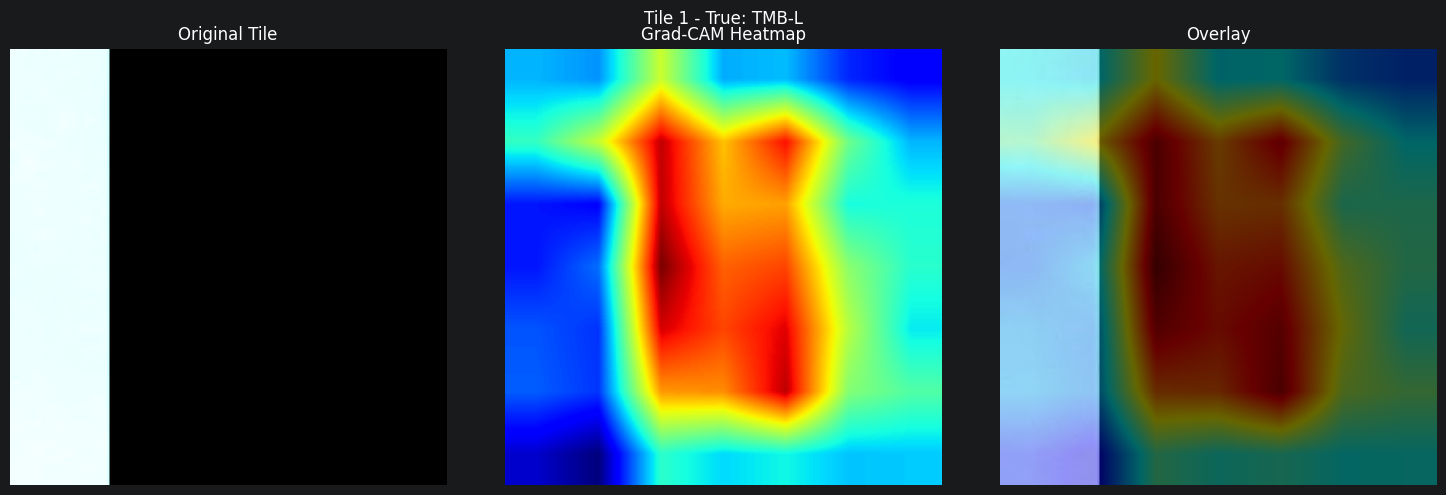

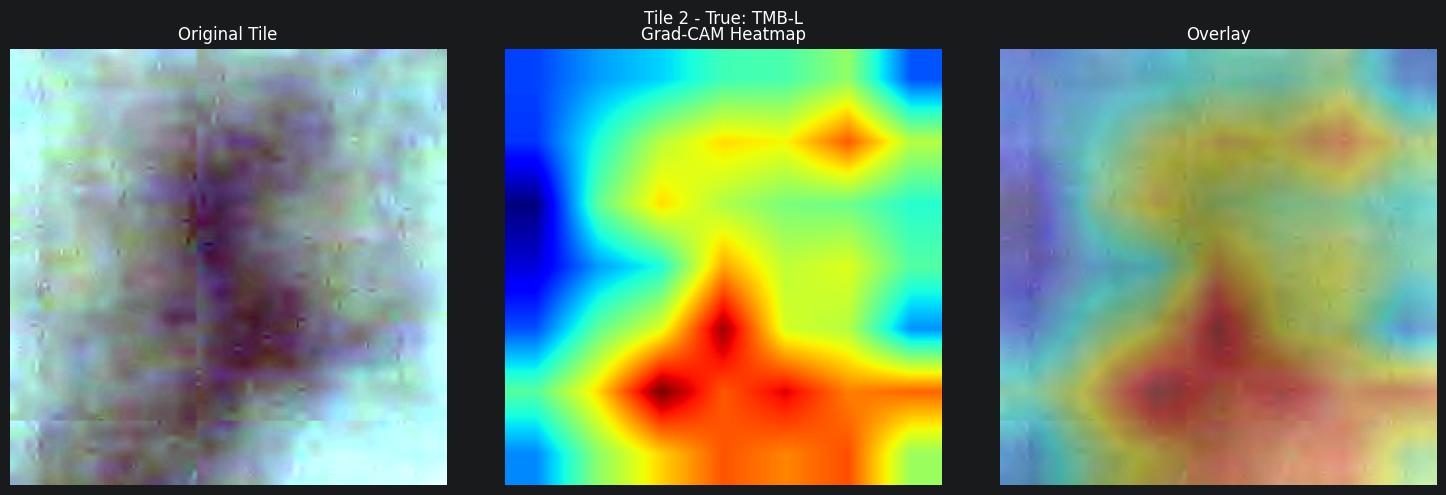

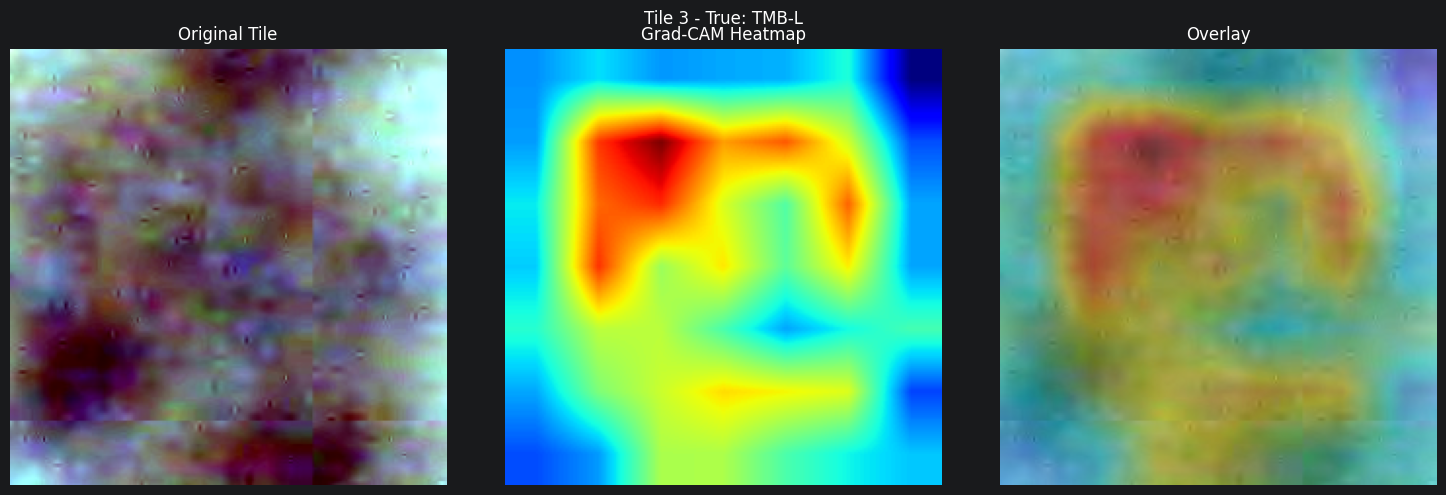


Generating SHAP explanations...
✓ SHAP explanation saved to: members/youssef/experiments/CellMorphNet/figures/shap_explanation.png


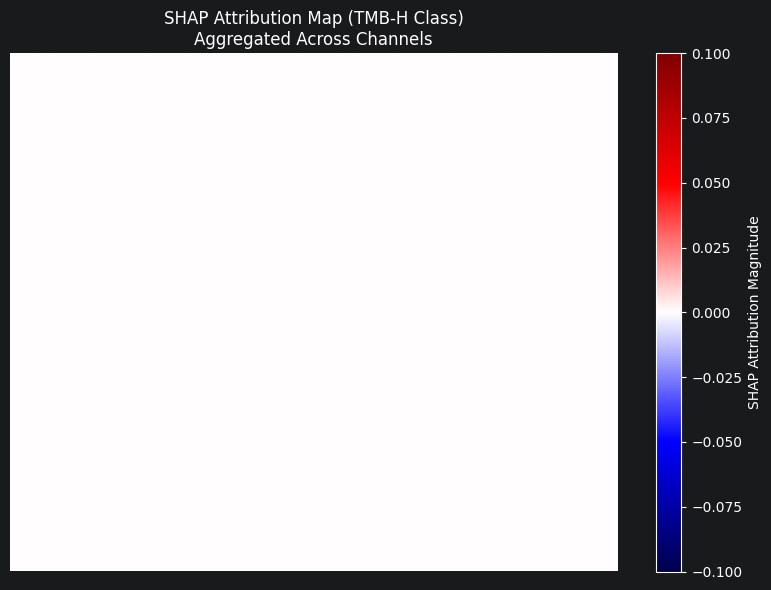


Generating LIME explanation...


100%|██████████| 300/300 [00:01<00:00, 257.68it/s]


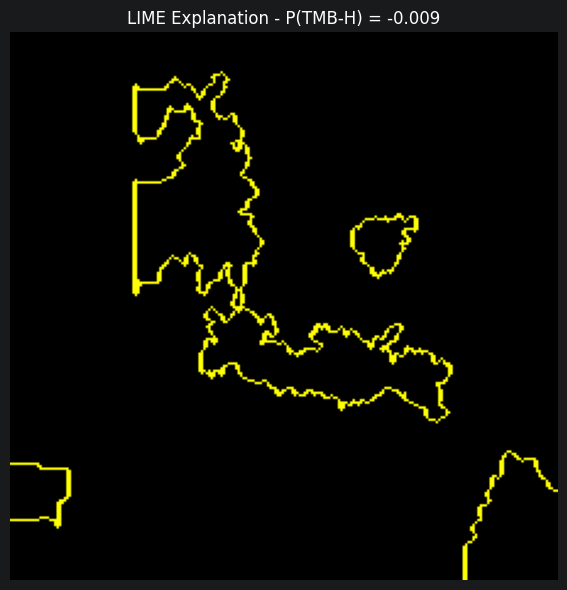


Computing Partial Dependence Plot...


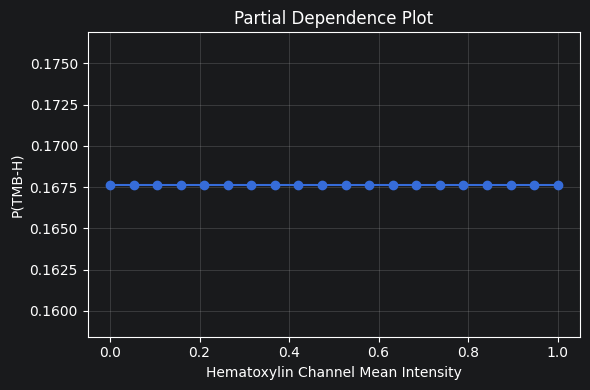


Skipping statistical comparison because multi-seed results are not available.

✓ All outputs saved to: members/youssef/experiments/CellMorphNet/checkpoints
✓ Figures saved to: members/youssef/experiments/CellMorphNet/figures


In [12]:
# ## §12 — Main Execution

def main():
    """Main execution pipeline."""
    
    print(f"Project root: {PROJECT_ROOT}")
    print(f"Tiles directory: {TILES_DIR}")
    
    # Load cohort labels from the workspace artifacts used by preprocessing.
    label_candidates = [
        DATA_DIR / 'model_cohort.csv',
        PROJECT_ROOT / 'model_cohort.csv',
        DATA_DIR / 'cohort_phase2.csv',
        PROJECT_ROOT / 'cohort_phase2.csv',
        TABULAR_DIR / 'coad_tcga_gdc' / 'patient.tsv',
    ]
    labels_path = next((p for p in label_candidates if p.exists()), None)
    if labels_path is not None:
        labels_df = pd.read_csv(labels_path)
        labels_df.columns = [c.lower() for c in labels_df.columns]
        if 'tmb_label' not in labels_df.columns:
            if 'tmb_nonsynonymous' not in labels_df.columns:
                raise ValueError(f"No TMB label column found in {labels_path}")
            labels_df['tmb_label'] = (labels_df['tmb_nonsynonymous'] >= CONFIG['tmb_high_threshold']).astype(int)
        labels_df = labels_df[['patient_id', 'tmb_label']].dropna().drop_duplicates('patient_id')
    else:
        print("Warning: Labels file not found. Creating synthetic labels for demo.")
        patients = sorted([p.name for p in TILES_DIR.iterdir() if p.is_dir()])
        if not patients:
            raise FileNotFoundError(f"No patient folders found under {TILES_DIR}")
        patients = patients[:min(100, len(patients))]
        labels_df = pd.DataFrame({
            'patient_id': patients,
            'tmb_label': np.random.randint(0, 2, size=len(patients)),
        })

    # Create dataloaders
    train_loader, val_loader, test_loader, class_weights = create_dataloaders(
        TILES_DIR, labels_df, CONFIG['batch_size']
    )
    print(f"Train: {len(train_loader.dataset)}, Val: {len(val_loader.dataset)}, Test: {len(test_loader.dataset)}")
    
    # Update class weights in config
    CONFIG['class_weights'] = class_weights
    
    # Run multi-seed training & evaluation (skip if best model already exists)
    output_dir = Path('members/youssef/experiments/CellMorphNet/checkpoints')
    output_dir.mkdir(parents=True, exist_ok=True)

    checkpoint_path = output_dir / 'best_model_seed42.pt'
    results_df, summary = None, None
    if checkpoint_path.exists():
        print(f"Found existing checkpoint: {checkpoint_path}. Skipping training and loading model.")
        # We still created dataloaders above and can proceed to explanations/eval
    else:
        results_df, summary = run_multi_seed_evaluation(
            CellMorphNet, train_loader, val_loader, test_loader,
            CONFIG, SEEDS, output_dir
        )

    # Final evaluation on best model (seed 42)
    print("\nLoading best model for explainability demos...")
    # Prefer seed42 checkpoint; otherwise pick the best available checkpoint by val_auc
    best_checkpoint = output_dir / 'best_model_seed42.pt'
    if not best_checkpoint.exists():
        candidates = list(output_dir.glob('best_model_seed*.pt')) if output_dir.exists() else []
        if not candidates:
            raise FileNotFoundError(
                f"No best_model checkpoint found in {output_dir}. Run training or place a checkpoint there."
            )
        # Choose the checkpoint with highest saved val_auc
        best_auc = -1.0
        best_checkpoint = None
        for c in candidates:
            try:
                meta = torch.load(c, map_location='cpu')
                val = float(meta.get('val_auc', -1.0))
                if val > best_auc:
                    best_auc = val
                    best_checkpoint = c
            except Exception:
                continue
        if best_checkpoint is None:
            raise FileNotFoundError(f"No valid checkpoint found among: {candidates}")
        print(f"Selected checkpoint {best_checkpoint} with val_auc={best_auc:.4f}")

    best_model = CellMorphNet(num_classes=CONFIG['num_classes'])
    checkpoint = torch.load(best_checkpoint, map_location=DEVICE)
    best_model.load_state_dict(checkpoint['model_state_dict'])
    best_model = best_model.to(DEVICE)
    
    # Get a test batch for explainability
    test_batch = next(iter(test_loader))
    test_imgs, test_labels = test_batch[0][:3].to(DEVICE), test_batch[1][:3]
    
    # === EXPLAINABILITY DEMOS ===
    
    # 1. Grad-CAM
    print("\nGenerating Grad-CAM visualizations...")
    for i in range(min(3, len(test_imgs))):
        heatmap, overlay = compute_gradcam(best_model, test_imgs[i], device=DEVICE)
        if heatmap is not None:
            fig, axes = plt.subplots(1, 3, figsize=(15, 5))
            orig = test_imgs[i].permute(1, 2, 0).cpu().numpy()
            orig = orig * np.array([0.229, 0.456, 0.406]) + np.array([0.485, 0.456, 0.406])
            axes[0].imshow(np.clip(orig, 0, 1))
            axes[0].set_title('Original Tile')
            axes[0].axis('off')
            axes[1].imshow(heatmap, cmap='jet')
            axes[1].set_title('Grad-CAM Heatmap')
            axes[1].axis('off')
            axes[2].imshow(overlay)
            axes[2].set_title('Overlay')
            axes[2].axis('off')
            plt.suptitle(f'Tile {i+1} - True: TMB-{"H" if test_labels[i]==1 else "L"}')
            plt.tight_layout()
            plt.savefig(FIGURES_DIR / f'gradcam_tile{i+1}.png', dpi=300)
            plt.show()
    
    # 2. SHAP (on CPU for memory)
    print("\nGenerating SHAP explanations...")
    # Use a small background set (need at least a few samples for robust SHAP baseline)
    background_sample = [test_imgs[0].cpu().numpy()] * 5
    test_sample = [test_imgs[0].cpu().numpy()]

    shap_vals = explain_with_shap(best_model, background_sample, test_sample,
                                   DEVICE, target_class=1)  # Explain TMB-H prediction

    if shap_vals is not None:
        # Convert to array and handle variable shapes
        sv = np.asarray(shap_vals)

        # Extract first test sample and aggregate across channels/classes
        # SHAP may return (N, C, H, W, classes) or (N, C, H, W) or (C, H, W) etc.
        if sv.ndim == 5:
            # (N, C, H, W, classes) - take first sample, average channels and classes
            shap_heatmap = np.abs(sv[0]).mean(axis=(0, -1))
        elif sv.ndim == 4:
            # (N, C, H, W) - take first sample and mean across channels
            shap_heatmap = np.abs(sv[0]).mean(axis=0)
        elif sv.ndim == 3:
            # Could be (C, H, W) or (H, W, C) - detect and handle
            if sv.shape[0] in (1, 3):  # First dim is channels
                shap_heatmap = np.abs(sv).mean(axis=0)
            elif sv.shape[-1] in (1, 3):  # Last dim is channels
                shap_heatmap = np.abs(sv).mean(axis=-1)
            else:
                shap_heatmap = np.abs(sv[0]) if sv.shape[0] > 1 else np.abs(sv)
        elif sv.ndim == 2:
            shap_heatmap = np.abs(sv)
        else:
            print(f"Unexpected SHAP shape: {sv.shape}, attempting recovery...")
            shap_heatmap = np.abs(sv).mean(axis=tuple(range(sv.ndim - 2)))

        if shap_heatmap is not None:
            # Ensure 2D: keep reducing dimensions until we have exactly 2D
            while shap_heatmap.ndim > 2:
                shap_heatmap = shap_heatmap.mean(axis=-1)

            # Normalize for better visualization
            shap_min, shap_max = shap_heatmap.min(), shap_heatmap.max()
            if shap_max > shap_min:
                shap_heatmap = (shap_heatmap - shap_min) / (shap_max - shap_min)

            # Create and save visualization
            fig, ax = plt.subplots(figsize=(8, 6))
            im = ax.imshow(shap_heatmap, cmap='seismic', aspect='auto')
            cbar = plt.colorbar(im, ax=ax, label='SHAP Attribution Magnitude')
            ax.set_title('SHAP Attribution Map (TMB-H Class)\nAggregated Across Channels')
            ax.axis('off')

            # Ensure output directory exists
            FIGURES_DIR.mkdir(parents=True, exist_ok=True)
            shap_save_path = FIGURES_DIR / 'shap_explanation.png'

            plt.tight_layout()
            plt.savefig(shap_save_path, dpi=300, bbox_inches='tight')
            print(f"✓ SHAP explanation saved to: {shap_save_path}")
            plt.show()
    else:
        print("⚠ SHAP explanation generation failed or returned None")

    # 3. LIME
    print("\nGenerating LIME explanation...")
    test_img_np = test_imgs[0].permute(1, 2, 0).cpu().numpy()
    test_img_np = test_img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    test_img_np = np.clip(test_img_np, 0, 1)
    
    lime_exp = explain_with_lime(best_model, test_img_np, DEVICE, num_samples=300)
    if lime_exp is not None:
        temp, mask = lime_exp.get_image_and_mask(
            lime_exp.top_labels[0], positive_only=True, num_features=10, hide_rest=False
        )
        plt.figure(figsize=(8, 6))
        plt.imshow(mark_boundaries(temp / 255.0, mask))
        plt.title(f'LIME Explanation - P(TMB-H) = {lime_exp.local_exp[lime_exp.top_labels[0]][0][1]:.3f}')
        plt.axis('off')
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / 'lime_explanation.png', dpi=300)
        plt.show()
    
    # 4. PDP (simplified demo)
    print("\nComputing Partial Dependence Plot...")
    # Demo: PDP for mean stain intensity (Hematoxylin channel)
    def extract_hematoxylin_mean(img):
        """Extract mean Hematoxylin stain intensity."""
        return img[0].mean().item()  # First channel after deconv
    
    x_vals, pdp_vals = compute_pdp(
        best_model, extract_hematoxylin_mean, 'Hematoxylin Intensity',
        feature_range=(0.0, 1.0), background_data=[test_img_np], 
        device=DEVICE, n_points=20
    )
    
    plt.figure(figsize=(6, 4))
    plt.plot(x_vals, pdp_vals, marker='o')
    plt.xlabel('Hematoxylin Channel Mean Intensity')
    plt.ylabel('P(TMB-H)')
    plt.title('Partial Dependence Plot')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'pdp_hematoxylin.png', dpi=300)
    plt.show()
    
    # Statistical comparison (only if we ran multi-seed training)
    stat_results = None
    if results_df is not None:
        print("\nRunning statistical comparison...")
        stat_results = statistical_test(results_df.to_dict('records'), paper_baseline_auc=0.915)
    else:
        print("\nSkipping statistical comparison because multi-seed results are not available.")

    # Save final summary
    summary_path = output_dir / 'final_summary.json'
    import json
    with open(summary_path, 'w') as f:
        json.dump({
            'multi_seed_summary': summary.to_dict() if summary is not None else {},
            'statistical_test': stat_results,
            'config': CONFIG,
        }, f, indent=2)
    
    print(f"\n✓ All outputs saved to: {output_dir}")
    print(f"✓ Figures saved to: {FIGURES_DIR}")
    
    return summary, stat_results

if __name__ == '__main__':
    main()